In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!ls /content/drive


MyDrive


In [ ]:
!ls "/content/drive/MyDrive/shemagh_project"


dal-shemagh-detection-challenge      submission.csv		 yolo11n.pt
dal-shemagh-detection-challenge.zip  submission_final_clean.csv  yolo26n.pt
dataset				     submission_final.csv	 yolov8l.pt
data.yaml			     submission_fixed.csv	 yolov8m.pt
__MACOSX			     submission_kaggle_safe.csv  yolov8n.pt
runs				     submission_ready.csv


In [ ]:
!cat "/content/drive/MyDrive/shemagh_project/data.yaml"


names:
  0: person
  1: shemagh
path: /content/drive/MyDrive/shemagh_project/dal-shemagh-detection-challenge
train: images/train
val: images/train


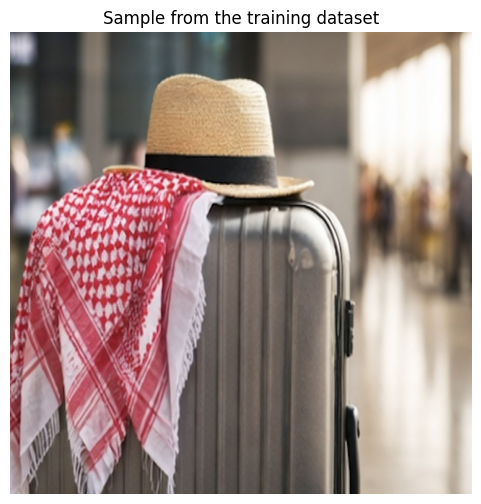

In [ ]:
import os
import random
import cv2
import matplotlib.pyplot as plt

images_path = "/content/drive/MyDrive/shemagh_project/dal-shemagh-detection-challenge/images/train"

image_file = random.choice(os.listdir(images_path))
image_path = os.path.join(images_path, image_file)

img = cv2.imread(image_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6,6))
plt.imshow(img)
plt.axis("off")
plt.title("Sample from the training dataset")
plt.show()


In [ ]:
!ls "/content/drive/MyDrive/shemagh_project/dal-shemagh-detection-challenge"


data.yaml  images  labels  train_labels.csv


In [ ]:
!pip install ultralytics


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 72.6 MB/s eta 0:00:00


In [ ]:
%cd /content/drive/MyDrive/shemagh_project
!unzip -o dal-shemagh-detection-challenge.zip


/content/drive/MyDrive/shemagh_project
Archive:  dal-shemagh-detection-challenge.zip
  inflating: __MACOSX/._dal-shemagh-detection-challenge  
  inflating: dal-shemagh-detection-challenge/train_labels.csv  
  inflating: __MACOSX/dal-shemagh-detection-challenge/._train_labels.csv  
  inflating: __MACOSX/dal-shemagh-detection-challenge/._images  
  inflating: __MACOSX/dal-shemagh-detection-challenge/._labels  
  inflating: __MACOSX/dal-shemagh-detection-challenge/images/._test  
  inflating: __MACOSX/dal-shemagh-detection-challenge/images/._train  
  inflating: __MACOSX/dal-shemagh-detection-challenge/labels/._train  
  inflating: dal-shemagh-detection-challenge/images/test/63.jpg  
  inflating: __MACOSX/dal-shemagh-detection-challenge/images/test/._63.jpg  
  inflating: dal-shemagh-detection-challenge/images/test/823.jpg  
  inflating: __MACOSX/dal-shemagh-detection-challenge/images/test/._823.jpg  
  inflating: dal-shemagh-detection-challenge/images/test/189.jpg  
  inflating: __MACOSX

In [ ]:
import os, random, shutil
from pathlib import Path

ROOT = Path("/content/drive/MyDrive/shemagh_project/dal-shemagh-detection-challenge")

img_train = ROOT/"images/train"
lbl_train = ROOT/"labels/train"
img_val   = ROOT/"images/val"
lbl_val   = ROOT/"labels/val"

img_val.mkdir(parents=True, exist_ok=True)
lbl_val.mkdir(parents=True, exist_ok=True)

imgs = list(img_train.glob("*.jpg")) + list(img_train.glob("*.png")) + list(img_train.glob("*.jpeg"))

random.seed(42)
val_count = int(0.15 * len(imgs))
val_imgs = random.sample(imgs, val_count)

for img_path in val_imgs:
    name = img_path.stem
    label_path = lbl_train / (name + ".txt")

    shutil.move(str(img_path), str(img_val / img_path.name))

    if label_path.exists():
        shutil.move(str(label_path), str(lbl_val / label_path.name))

print("✅ Done split")
print("Train images:", len(list(img_train.glob("*"))))
print("Val images:", len(list(img_val.glob("*"))))


✅ Done split
Train images: 554
Val images: 590


In [ ]:
!pip3 install requests beautifulsoup4 matplotlib

In [ ]:
from ultralytics import YOLO


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
from ultralytics import YOLO
model = YOLO("yolov8l.pt")

model.train(
    data="/content/drive/MyDrive/shemagh_project/data.yaml",
    epochs=120,
    imgsz=768,
    batch=8,
    lr0=0.003,
)


Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.9.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/shemagh_project/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=120, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=768, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.003, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8l.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train41, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_ma

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7a257eb89490>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04804

In [ ]:
from ultralytics import YOLO

model = YOLO("/content/drive/MyDrive/shemagh_project/runs/detect/train37/weights/best.pt")


In [ ]:
results = model.predict(
    source="/content/drive/MyDrive/shemagh_project/dal-shemagh-detection-challenge/images/test",
    conf=0.10,
    save=False
)



image 1/842 /content/drive/MyDrive/shemagh_project/dal-shemagh-detection-challenge/images/test/0.jpg: 768x768 1 person, 11.6ms
image 2/842 /content/drive/MyDrive/shemagh_project/dal-shemagh-detection-challenge/images/test/1.jpg: 768x768 2 shemaghs, 10.4ms
image 3/842 /content/drive/MyDrive/shemagh_project/dal-shemagh-detection-challenge/images/test/10.jpg: 768x768 (no detections), 10.2ms
image 4/842 /content/drive/MyDrive/shemagh_project/dal-shemagh-detection-challenge/images/test/100.jpg: 768x768 3 shemaghs, 10.3ms
image 5/842 /content/drive/MyDrive/shemagh_project/dal-shemagh-detection-challenge/images/test/101.jpg: 768x768 1 shemagh, 10.7ms
image 6/842 /content/drive/MyDrive/shemagh_project/dal-shemagh-detection-challenge/images/test/102.jpg: 768x768 (no detections), 10.6ms
image 7/842 /content/drive/MyDrive/shemagh_project/dal-shemagh-detection-challenge/images/test/103.jpg: 768x768 1 person, 9.9ms
image 8/842 /content/drive/MyDrive/shemagh_project/dal-shemagh-detection-challenge/

In [ ]:
model = YOLO("runs/detect/train37/weights/best.pt")


In [ ]:
!ls -lah /content
!ls -lah /content/drive
!ls -lah /content/drive/MyDrive | head


total 20K
drwxr-xr-x 1 root root 4.0K Feb  6 20:21 .
drwxr-xr-x 1 root root 4.0K Feb  6 20:17 ..
drwxr-xr-x 4 root root 4.0K Dec  9 14:41 .config
drwx------ 5 root root 4.0K Feb  6 20:21 drive
drwxr-xr-x 1 root root 4.0K Dec  9 14:42 sample_data
total 16K
dr-x------ 4 root root 4.0K Feb  6 20:21 .Encrypted
drwx------ 4 root root 4.0K Feb  6 20:21 MyDrive
dr-x------ 2 root root 4.0K Feb  6 20:21 .shortcut-targets-by-id
drwx------ 5 root root 4.0K Feb  6 20:21 .Trash-0
total 3.2M
-rw------- 1 root root  274K Nov 23 21:28 Airline.ipynb 5
drwx------ 2 root root  4.0K Sep 11 12:16 Colab Notebooks
-rw------- 1 root root   24K Apr  6  2024 Copy of JavaProject2.drawio
-rw------- 1 root root   48K Apr 18  2024 Copy of JavaProjectLASTCOPY.drawio
-rw------- 1 root root   62K Apr 18  2024 Copy of JavaProject.LASTversion.drawio.pdf
-rw------- 1 root root   62K Apr 18  2024 Copy of JavaProjectnew (1).LAST.drawio.pdf
-rw------- 1 root root   62K Apr 18  2024 Copy of JavaProjectnew (2).LAST.drawio.pdf

In [ ]:
!ls -lah "/content/drive/MyDrive" | grep -i shemagh
!ls -lah "/content/drive/MyDrive/shemagh_project"


drwx------ 6 root root  4.0K Feb  6 21:51 shemagh_project
total 302M
drwx------ 4 root root 4.0K Feb  6 20:23 dal-shemagh-detection-challenge
-rw------- 1 root root 157M Feb  5 17:24 dal-shemagh-detection-challenge.zip
drwx------ 4 root root 4.0K Feb  5 17:24 dataset
-rw------- 1 root root  150 Feb  6 09:17 data.yaml
drwx------ 3 root root 4.0K Feb  6 20:23 __MACOSX
drwx------ 3 root root 4.0K Feb  5 18:23 runs
-rw------- 1 root root  40K Feb  6 21:03 submission.csv
-rw------- 1 root root  38K Feb  6 21:47 submission_final_clean.csv
-rw------- 1 root root  38K Feb  6 21:38 submission_final.csv
-rw------- 1 root root  40K Feb  6 21:06 submission_fixed.csv
-rw------- 1 root root  42K Feb  6 21:51 submission_ready.csv
-rw------- 1 root root 5.3M Feb  6 13:17 yolo26n.pt
-rw------- 1 root root  84M Feb  6 20:25 yolov8l.pt
-rw------- 1 root root  50M Feb  5 18:23 yolov8m.pt
-rw------- 1 root root 6.3M Feb  6 06:45 yolov8n.pt


In [ ]:
!find "/content/drive/MyDrive/shemagh_project" -maxdepth 4 -name "sample_submission.csv"
!find "/content/drive/MyDrive/shemagh_project" -maxdepth 6 -name "best.pt"
!find "/content/drive/MyDrive/shemagh_project" -maxdepth 6 -type d -path "*images/test"


find: ‘/content/drive/MyDrive/shemagh_project’: No such file or directory
find: ‘/content/drive/MyDrive/shemagh_project’: No such file or directory
find: ‘/content/drive/MyDrive/shemagh_project’: No such file or directory


In [ ]:
MODEL_PATH = "PUT_THE_PRINTED_PATH_TO_best.pt_HERE"
TEST_DIR   = "PUT_THE_PRINTED_PATH_TO_images/test_HERE"
sample_path = "PUT_THE_PRINTED_PATH_TO_sample_submission.csv_HERE"


In [ ]:
import os
import pandas as pd
from ultralytics import YOLO

# -------------------------
# 1) Load trained model
# -------------------------
MODEL_PATH = "/content/drive/MyDrive/shemagh_project/runs/detect/train37/weights/best.pt"
model = YOLO(MODEL_PATH)

# -------------------------
# 2) Test folder path
# -------------------------
TEST_DIR = "/content/drive/MyDrive/shemagh_project/dal-shemagh-detection-challenge/images/test"

# -------------------------
# 3) Predict on all test images
# -------------------------
all_predictions = []

for file in sorted(os.listdir(TEST_DIR)):
    if file.endswith(".jpg") or file.endswith(".png"):

        img_path = os.path.join(TEST_DIR, file)

        results = model.predict(img_path, conf=0.25, iou=0.5, verbose=False)

        pred_string = ""

        for r in results:
            boxes = r.boxes
            if boxes is not None and len(boxes) > 0:
                for box in boxes:
                    cls = int(box.cls[0])
                    conf = float(box.conf[0])
                    x1, y1, x2, y2 = box.xyxy[0].tolist()

                    pred_string += f"{cls} {conf:.4f} {x1:.2f} {y1:.2f} {x2:.2f} {y2:.2f} "

        pred_string = pred_string.strip()

        # IMPORTANT: must never be NaN
        if pred_string is None:
            pred_string = ""

        all_predictions.append([file.replace(".jpg","").replace(".png",""), pred_string])

# -------------------------
# 4) Create submission dataframe
# -------------------------
submission = pd.DataFrame(all_predictions, columns=["ID", "PredictionString"])

# -------------------------
# 5) Fix any NaNs (just in case)
# -------------------------
submission["ID"] = submission["ID"].fillna("")
submission["PredictionString"] = submission["PredictionString"].fillna("")

# -------------------------
# 6) Save csv
# -------------------------
submission.to_csv("submission_final.csv", index=False)

print("✅ submission_final.csv created!")
print(submission.head())
print("Nulls check:\n", submission.isnull().sum())


KeyboardInterrupt: 

In [ ]:
import os
import pandas as pd
from ultralytics import YOLO

# ✅ 1) Load your trained model (change train37 if needed)
MODEL_PATH = "/content/drive/MyDrive/shemagh_project/runs/detect/train37/weights/best.pt"
model = YOLO(MODEL_PATH)

# ✅ 2) Test images folder (make sure this exists)
TEST_DIR = "/content/drive/MyDrive/shemagh_project/dal-shemagh-detection-challenge/images/test"

# ✅ 3) Predict + build submission rows
rows = []

for fname in sorted(os.listdir(TEST_DIR)):
    if not (fname.lower().endswith(".jpg") or fname.lower().endswith(".png")):
        continue

    img_path = os.path.join(TEST_DIR, fname)

    results = model.predict(img_path, conf=0.25, iou=0.5, verbose=False)

    pred_parts = []
    for r in results:
        boxes = r.boxes
        if boxes is None or len(boxes) == 0:
            continue

        for box in boxes:
            cls = int(box.cls[0])
            conf = float(box.conf[0])
            x1, y1, x2, y2 = box.xyxy[0].tolist()
            pred_parts.append(f"{cls} {conf:.4f} {x1:.2f} {y1:.2f} {x2:.2f} {y2:.2f}")

    pred_string = " ".join(pred_parts)  # empty string if none
    rows.append([fname, pred_string])

# ✅ 4) Create submission with the EXACT expected headers
sub = pd.DataFrame(rows, columns=["filename", "PredictionString"])

# ✅ 5) HARD FIX for nulls (this removes ANY NaN)
sub["filename"] = sub["filename"].astype(str).fillna("")
sub["PredictionString"] = sub["PredictionString"].astype(str).fillna("")

# ✅ 6) Extra safety checks (print problems if any)
print("Shape:", sub.shape)
print("Nulls:", sub.isna().sum())
print("Empty filename count:", (sub["filename"].str.strip() == "").sum())

# ✅ 7) Save clean file
OUT_CSV = "submission_ready.csv"
sub.to_csv(OUT_CSV, index=False)

print("✅ Saved:", OUT_CSV)
print(sub.head())


ModuleNotFoundError: No module named 'ultralytics'

In [ ]:
from google.colab import files
files.download("submission_ready.csv")


FileNotFoundError: Cannot find file: submission_ready.csv